# Student Case Study — the same pipeline on a different dataset

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · **▶ 05 Feature Engineering** · 06 Regression · 07 Model Prep · 08 Case Studies · 09 Deployment

`05_Feature_Engineering/05_student_case_study_full_pipeline.ipynb`

---

### In one paragraph (no jargon)

The same three-stage pipeline as the sales case study, applied to student records. Working the identical process on different data is the fastest way to see which parts are the *method* and which parts are just these particular column names — which is exactly what you need to be able to tell apart in an exam.

### After this notebook you can

- Repeat the split → extract → filter → encode pipeline on a new dataset
- Convert an ordinal grade into numbers that preserve the ranking
- Build age bands and an employment flag
- Recognise the reusable shape of the pipeline


### What's inside

1. Stage 1 — Feature splitting
2. Stage 2 — Feature extraction
3. Stage 3 — Filtering and encoding
4. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Feature** | One column used as an input to a model. |
| **Feature engineering** | Creating better columns from the ones you have — the step that usually improves a model more than changing the algorithm. |
| **Feature extraction** | Pulling a new column out of an existing one: month out of a date, title out of a name. |
| **Feature splitting** | Breaking one column into several: `"Yangon(Local)"` → city + type. |
| **Derived feature** | A column computed from others: profit = revenue − cost. |
| **Domain knowledge** | Knowing what the numbers mean in the business. This is what makes a good feature; no algorithm can supply it. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")
import tempfile
# WHY: the stages below save their output and the next stage reads it back,
#      exactly as the original separate notebooks did. Those intermediate files
#      go to a temporary folder so running this notebook leaves your notes clean.
EXPORT_DIR = tempfile.mkdtemp(prefix='bda_exports_')
print('Intermediate files for this notebook:', EXPORT_DIR)

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_student():
    """Exact copy of student.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Student_id,Age,Gender,Grade,Employed
1,19,Male,1st Class,yes
2,20,Female,2nd Class,no
3,18,Male,1st Class,no
4,21,Female,2nd Class,no
5,19,Male,1st Class,no
6,20,Male,2nd Class,yes
7,19,Female,3rd Class,yes
8,21,Male,3rd Class,yes
9,22,Female,3rd Class,yes
10,21,Male,1st Class,no
11,20,Female,3rd Class,yes
12,20,Male,1st Class,no
13,19,Male,1st Class,yes
14,20,Female,3rd Class,no
15,19,Male,1st Class,yes
16,19,Female,2nd Class,no
17,20,Male,2nd Class,yes
18,18,Female,3rd Class,no
19,21,Male,2nd Class,yes
20,19,Male,2nd Class,no
21,20,Female,3rd Class,yes
22,19,Male,2nd Class,no
23,21,Female,2nd Class,yes
24,22,Male,3rd Class,no
25,21,Female,1st Class,no
26,20,Male,2nd Class,no
27,20,Male,3rd Class,no
28,19,Female,1st Class,no
29,20,Male,3rd Class,no
30,19,Male,1st Class,yes
31,20,Female,2nd Class,no
32,18,Male,1st Class,no
33,21,Female,2nd Class,no
34,19,Male,1st Class,no
35,20,Male,2nd Class,yes
36,19,Female,3rd Class,yes
37,21,Male,3rd Class,yes
38,22,Female,3rd Class,yes
39,21,Male,1st Class,no
40,20,Female,3rd Class,yes
41,20,Male,1st Class,no
42,19,Male,1st Class,yes
43,20,Female,3rd Class,no
44,19,Male,1st Class,yes
45,19,Female,2nd Class,no
46,20,Male,2nd Class,yes
47,18,Female,3rd Class,no
48,21,Male,2nd Class,yes
49,19,Male,2nd Class,no
50,20,Female,3rd Class,yes
51,19,Male,2nd Class,no
52,21,Female,2nd Class,yes
53,22,Male,3rd Class,no
54,21,Female,1st Class,no
55,20,Male,2nd Class,no
56,20,Male,3rd Class,no
57,19,Female,1st Class,no
58,20,Male,3rd Class,no
59,19,Male,1st Class,yes
60,20,Female,2nd Class,no
61,18,Male,1st Class,no
62,21,Female,2nd Class,no
63,19,Male,1st Class,no
64,20,Male,2nd Class,yes
65,19,Female,3rd Class,yes
66,21,Male,3rd Class,yes
67,22,Female,3rd Class,yes
68,21,Male,1st Class,no
69,20,Female,3rd Class,yes
70,20,Male,1st Class,no
71,19,Male,1st Class,yes
72,20,Female,3rd Class,no
73,19,Male,1st Class,yes
74,19,Female,2nd Class,no
75,20,Male,2nd Class,yes
76,18,Female,3rd Class,no
77,21,Male,2nd Class,yes
78,19,Male,2nd Class,no
79,20,Female,3rd Class,yes
80,19,Male,2nd Class,no
81,21,Female,2nd Class,yes
82,22,Male,3rd Class,no
83,21,Female,1st Class,no
84,20,Male,2nd Class,no
85,20,Male,3rd Class,no
86,19,Female,1st Class,no
87,20,Male,3rd Class,no
88,19,Male,1st Class,yes
89,20,Female,2nd Class,no
90,18,Male,1st Class,no
91,21,Female,2nd Class,no
92,19,Male,1st Class,no
93,20,Male,2nd Class,yes
94,19,Female,3rd Class,yes
95,21,Male,3rd Class,yes
96,22,Female,3rd Class,yes
97,21,Male,1st Class,no
98,20,Female,3rd Class,yes
99,20,Male,1st Class,no
100,19,Male,1st Class,yes
101,20,Female,3rd Class,no
102,19,Male,1st Class,yes
103,19,Female,2nd Class,no
104,20,Male,2nd Class,yes
105,18,Female,3rd Class,no
106,21,Male,2nd Class,yes
107,19,Male,2nd Class,no
108,20,Female,3rd Class,yes
109,19,Male,2nd Class,no
110,21,Female,2nd Class,yes
111,22,Male,3rd Class,no
112,21,Female,1st Class,no
113,20,Male,2nd Class,no
114,20,Male,3rd Class,no
115,19,Female,1st Class,no
116,20,Male,3rd Class,no
117,19,Male,1st Class,yes
118,20,Female,2nd Class,no
119,18,Male,1st Class,no
120,21,Female,2nd Class,no
121,19,Male,1st Class,no
122,20,Male,2nd Class,yes
123,19,Female,3rd Class,yes
124,21,Male,3rd Class,yes
125,22,Female,3rd Class,yes
126,21,Male,1st Class,no
127,20,Female,3rd Class,yes
128,20,Male,1st Class,no
129,19,Male,1st Class,yes
130,20,Female,3rd Class,no
131,19,Male,1st Class,yes
132,19,Female,2nd Class,no
133,20,Male,2nd Class,yes
134,18,Female,3rd Class,no
135,21,Male,2nd Class,yes
136,19,Male,2nd Class,no
137,20,Female,3rd Class,yes
138,19,Male,2nd Class,no
139,21,Female,2nd Class,yes
140,22,Male,3rd Class,no
141,21,Female,1st Class,no
142,20,Male,2nd Class,no
143,20,Male,3rd Class,no
144,19,Female,1st Class,no
145,20,Male,3rd Class,no
146,19,Male,1st Class,yes
147,20,Female,2nd Class,no
148,18,Male,1st Class,no
149,21,Female,2nd Class,no
150,19,Male,1st Class,no
151,20,Male,2nd Class,yes
152,19,Female,3rd Class,yes
153,21,Male,3rd Class,yes
154,22,Female,3rd Class,yes
155,21,Male,1st Class,no
156,20,Female,3rd Class,yes
157,20,Male,1st Class,no
158,19,Male,1st Class,yes
159,20,Female,3rd Class,no
160,19,Male,1st Class,yes
161,19,Female,2nd Class,no
162,20,Male,2nd Class,yes
163,18,Female,3rd Class,no
164,21,Male,2nd Class,yes
165,19,Male,2nd Class,no
166,20,Female,3rd Class,yes
167,19,Male,2nd Class,no
168,21,Female,2nd Class,yes
169,22,Male,3rd Class,no
170,21,Female,1st Class,no
171,20,Male,2nd Class,no
172,20,Male,3rd Class,no
173,19,Female,1st Class,no
174,20,Male,3rd Class,no
175,19,Male,1st Class,yes
176,20,Female,2nd Class,no
177,18,Male,1st Class,no
178,21,Female,2nd Class,no
179,19,Male,1st Class,no
180,20,Male,2nd Class,yes
181,19,Female,3rd Class,yes
182,21,Male,3rd Class,yes
183,22,Female,3rd Class,yes
184,21,Male,1st Class,no
185,20,Female,3rd Class,yes
186,20,Male,1st Class,no
187,19,Male,1st Class,yes
188,20,Female,3rd Class,no
189,19,Male,1st Class,yes
190,19,Female,2nd Class,no
191,20,Male,2nd Class,yes
192,18,Female,3rd Class,no
193,21,Male,2nd Class,yes
194,19,Male,2nd Class,no
195,20,Female,3rd Class,yes
196,19,Male,2nd Class,no
197,21,Female,2nd Class,yes
198,22,Male,3rd Class,no
199,21,Female,1st Class,no
200,20,Male,2nd Class,no
201,20,Male,3rd Class,no
202,19,Female,1st Class,no
203,20,Male,3rd Class,no
204,19,Male,1st Class,yes
205,20,Female,2nd Class,no
206,18,Male,1st Class,no
207,21,Female,2nd Class,no
208,19,Male,1st Class,no
209,20,Male,2nd Class,yes
210,19,Female,3rd Class,yes
211,21,Male,3rd Class,yes
212,22,Female,3rd Class,yes
213,21,Male,1st Class,no
214,20,Female,3rd Class,yes
215,20,Male,1st Class,no
216,19,Male,1st Class,yes
217,20,Female,3rd Class,no
218,19,Male,1st Class,yes
219,19,Female,2nd Class,no
220,20,Male,2nd Class,yes
221,18,Female,3rd Class,no
222,21,Male,2nd Class,yes
223,19,Male,2nd Class,no
224,20,Female,3rd Class,yes
225,19,Male,2nd Class,no
226,21,Female,2nd Class,yes
227,22,Male,3rd Class,no
228,21,Female,1st Class,no
229,20,Male,2nd Class,no
230,20,Male,3rd Class,yes
231,19,Female,1st Class,yes
232,20,Male,3rd Class,yes"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Intermediate files for this notebook: /tmp/bda_exports_wimy9ypw
Setup complete. pandas 3.0.2 | numpy 2.4.4


## Stage 1 — Feature splitting

Start by separating out the information packed into single columns.

# Feature Engineering — Student Dataset (Step 1: Feature Split)

**Dataset:** `student.csv` — 232 student records (Student_id, Age, Gender, Grade, Employed).

This is **Step 1 of 3** in the Student feature-engineering pipeline:
1. **Feature Split** (this notebook) — clean column names and split/convert compound or text-based fields into model-friendly forms
2. `feature_extraction_student.ipynb` — derive new features (ordinal grade mapping, age bins)
3. `student_filter_label_encoding.ipynb` — encode the remaining categorical columns

Each step reads the previous step's saved CSV, chained exactly like a real pipeline.

## 1. Load & inspect

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.dpi'] = 100

df = load_data('student.csv', rebuild=rebuild_student)
print(f"Shape: {df.shape}")
df.head()

Loaded 'student.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (232, 5)


,Student_id,Age,Gender,Grade,Employed
0,1,19,Male,1st Class,yes
1,2,20,Female,2nd Class,no
2,3,18,Male,1st Class,no
3,4,21,Female,2nd Class,no
4,5,19,Male,1st Class,no


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nUnique Grade values: {sorted(df['Grade'].unique())}")
print(f"Unique Employed values: {df['Employed'].unique()}")

Data types:
Student_id    int64
Age           int64
Gender          str
Grade           str
Employed        str
dtype: object

Missing values:
Student_id    0
Age           0
Gender        0
Grade         0
Employed      0
dtype: int64

Unique Grade values: ['1st Class', '2nd Class', '3rd Class']
Unique Employed values: <StringArray>
['yes', 'no']
Length: 2, dtype: str


## 2. Clean column names
Always strip stray whitespace from column names as a first defensive step — a column named `'Age '` (trailing space) silently fails to match `'Age'` in later code and is a classic source of `KeyError`s.

In [4]:
df.columns = df.columns.str.strip()
print(f"Cleaned column names: {df.columns.tolist()}")

Cleaned column names: ['Student_id', 'Age', 'Gender', 'Grade', 'Employed']


## 3. Converting a Yes/No text field into a binary flag
`Employed` is currently the strings `"yes"`/`"no"` — not directly usable by most ML algorithms, which expect numbers. We convert it to an explicit `0`/`1` flag. Note this is conceptually **binary label encoding**, done manually here for full transparency about the mapping (see `04_Data_Transformation/Categorical_Encoding/` for the general-purpose encoder-based approach).

In [5]:
df['Employed_flag'] = df['Employed'].str.lower().map({'yes': 1, 'no': 0})

print("Mapping check -- Employed vs. Employed_flag:")
df[['Employed', 'Employed_flag']].drop_duplicates()

Mapping check -- Employed vs. Employed_flag:


,Employed,Employed_flag
0,yes,1
1,no,0


## 4. Visualizing the split result

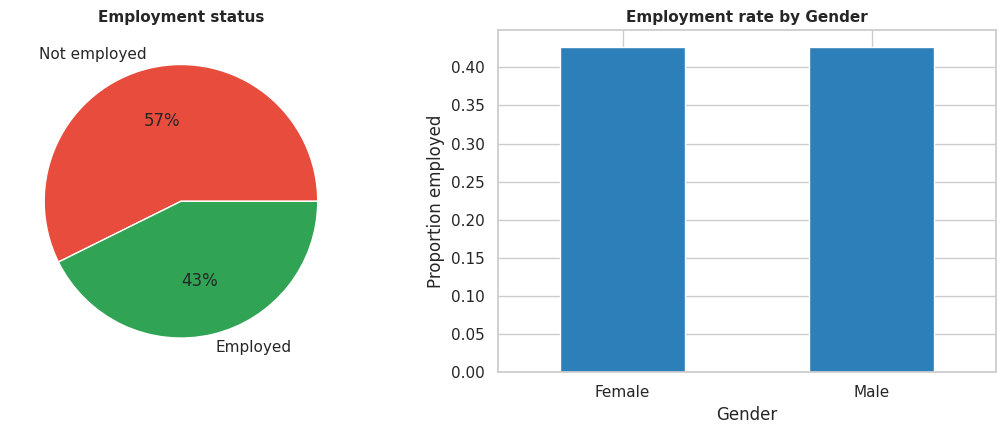

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df['Employed_flag'].value_counts().rename({0: 'Not employed', 1: 'Employed'}).plot(
    kind='pie', ax=axes[0], autopct='%1.0f%%', colors=['#e74c3c', '#31a354'])
axes[0].set_title('Employment status', fontweight='bold', fontsize=11)
axes[0].set_ylabel('')

df.groupby('Gender')['Employed_flag'].mean().plot(kind='bar', ax=axes[1], color='#2c7fb8')
axes[1].set_title('Employment rate by Gender', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Proportion employed')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Save for the next pipeline step

In [7]:
df.to_csv(os.path.join(EXPORT_DIR, 'student_feature_split.csv'), index=False)
print(f"Saved student_feature_split.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("Continue to feature_extraction_student.ipynb, which loads this exact file.")

Saved student_feature_split.csv -- 232 rows, 6 columns
Continue to feature_extraction_student.ipynb, which loads this exact file.


## Stage 2 — Feature extraction

Derive new columns: an employment flag, a numeric grade, an age band.

# Feature Engineering — Student Dataset (Step 2: Feature Extraction)

**Input:** `student_feature_split.csv` (produced by Step 1). This is **Step 2 of 3**: we derive two genuinely new features that didn't exist in the raw data — an ordinal numeric version of `Grade`, and an `Age_group` bucket.

## 1. Load Step 1's output

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(os.path.join(EXPORT_DIR, 'student_feature_split.csv'))
print(f"Shape: {df.shape}")
df.head()

Shape: (232, 6)


,Student_id,Age,Gender,Grade,Employed,Employed_flag
0,1,19,Male,1st Class,yes,1
1,2,20,Female,2nd Class,no,0
2,3,18,Male,1st Class,no,0
3,4,21,Female,2nd Class,no,0
4,5,19,Male,1st Class,no,0


## 2. Ordinal feature extraction: `Grade` -> `Grade_numeric`
`Grade` has a **natural order** (1st Class is better than 2nd, which is better than 3rd) that a plain label encoder wouldn't reliably preserve (it assigns codes alphabetically/by first appearance, not by academic rank). We map it explicitly instead — this is genuinely an **ordinal encoding**, done manually here for transparency (see the general-purpose `OrdinalEncoder` approach in `04_Data_Transformation/Categorical_Encoding/`).

In [9]:
grade_map = {"1st Class": 1, "2nd Class": 2, "3rd Class": 3}
df['Grade_numeric'] = df['Grade'].map(grade_map)

print("Verify the mapping preserves the real academic ranking (lower = better):")
df[['Grade', 'Grade_numeric']].drop_duplicates().sort_values('Grade_numeric')

Verify the mapping preserves the real academic ranking (lower = better):


,Grade,Grade_numeric
0,1st Class,1
1,2nd Class,2
6,3rd Class,3


## 3. Binning: `Age` -> `Age_group`
Converting the exact numeric age into a small number of meaningful buckets — see `04_Data_Transformation/Binning_Discretization/` for the full menu of binning strategies; this is a **custom/domain-driven** binning, using boundaries a student-affairs analyst might actually choose.

In [10]:
df['Age_group'] = pd.cut(df['Age'], bins=[0, 18, 20, 100], labels=['Teen', 'Young Adult', 'Adult'])

print(df[['Age', 'Age_group']].drop_duplicates().sort_values('Age').to_string(index=False))

 Age   Age_group
  18        Teen
  19 Young Adult
  20 Young Adult
  21       Adult
  22       Adult


## 4. Visualizing the extracted features

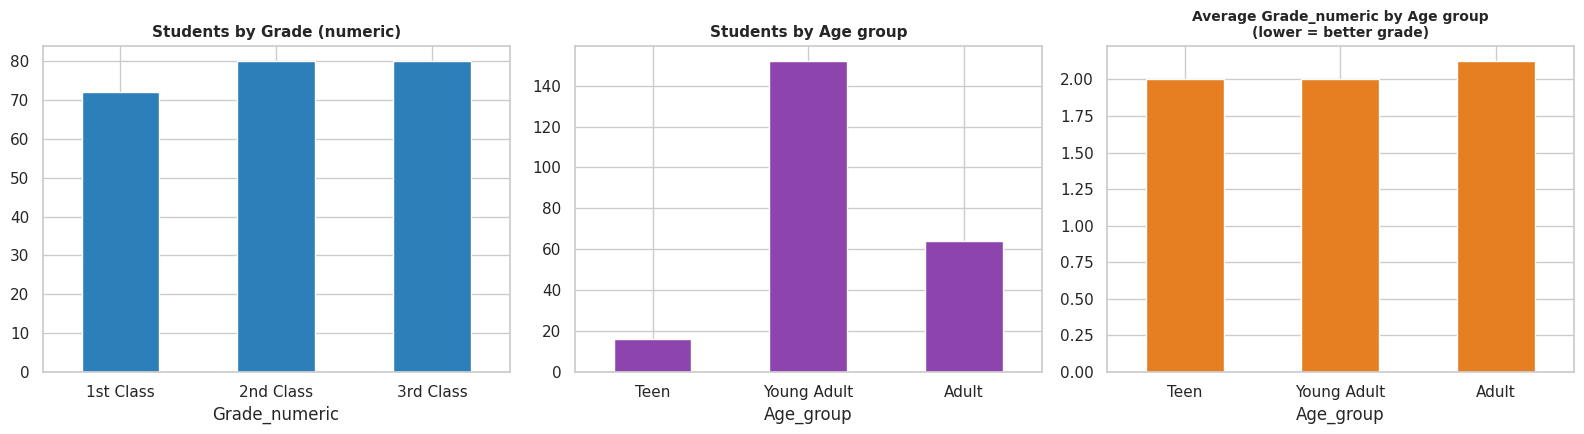

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['Grade_numeric'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2c7fb8')
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[0].set_title('Students by Grade (numeric)', fontweight='bold', fontsize=11)

df['Age_group'].value_counts().reindex(['Teen', 'Young Adult', 'Adult']).plot(kind='bar', ax=axes[1], color='#8e44ad')
axes[1].set_title('Students by Age group', fontweight='bold', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

df.groupby('Age_group', observed=True)['Grade_numeric'].mean().reindex(['Teen', 'Young Adult', 'Adult']).plot(
    kind='bar', ax=axes[2], color='#e67e22')
axes[2].set_title('Average Grade_numeric by Age group\n(lower = better grade)', fontweight='bold', fontsize=10)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Save for the next pipeline step

In [12]:
df.to_csv(os.path.join(EXPORT_DIR, 'student_feature_extraction.csv'), index=False)
print(f"Saved student_feature_extraction.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("Continue to student_filter_label_encoding.ipynb, which loads this exact file.")

Saved student_feature_extraction.csv -- 232 rows, 8 columns
Continue to student_filter_label_encoding.ipynb, which loads this exact file.


## Stage 3 — Filtering and encoding

Filter to the population of interest, then encode for modelling.

# Feature Engineering — Student Dataset (Step 3: Filtering & Label Encoding)

**Input:** `student_feature_extraction.csv` (produced by Step 2). This is **Step 3 of 3**: encode the remaining nominal (unordered) categorical columns — `Gender` and `Age_group` — completing the pipeline.

## 1. Load Step 2's output

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(os.path.join(EXPORT_DIR, 'student_feature_extraction.csv'))
print(f"Shape: {df.shape}")
df.head()

Shape: (232, 8)


,Student_id,Age,Gender,Grade,Employed,Employed_flag,Grade_numeric,Age_group
0,1,19,Male,1st Class,yes,1,1,Young Adult
1,2,20,Female,2nd Class,no,0,2,Young Adult
2,3,18,Male,1st Class,no,0,1,Teen
3,4,21,Female,2nd Class,no,0,2,Adult
4,5,19,Male,1st Class,no,0,1,Young Adult


## 2. Label-encode `Gender` and `Age_group`
`Gender` is binary (safe for label encoding — no implied order issue with only two values). `Age_group` is technically ordinal (`Teen < Young Adult < Adult`), so in a production pipeline you'd prefer an explicit `OrdinalEncoder` with the order specified (as shown in `04_Data_Transformation/Categorical_Encoding/`); we use `LabelEncoder` here to match the dataset's original intent, but flag the distinction so it isn't applied blindly elsewhere.

In [14]:
le_gender = LabelEncoder()
le_age_group = LabelEncoder()

df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['Age_group_encoded'] = le_age_group.fit_transform(df['Age_group'])

print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"Age_group mapping: {dict(zip(le_age_group.classes_, le_age_group.transform(le_age_group.classes_)))}")
print("\nNote: LabelEncoder assigns codes ALPHABETICALLY ('Adult'=0, 'Teen'=1, 'Young Adult'=2),")
print("which does NOT match the true age order (Teen < Young Adult < Adult) -- exactly the")
print("kind of silent mismatch that motivates using OrdinalEncoder with an explicit order instead.")

df[['Gender', 'Gender_encoded', 'Age_group', 'Age_group_encoded']].drop_duplicates()

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


Age_group mapping: {'Adult': np.int64(0), 'Teen': np.int64(1), 'Young Adult': np.int64(2)}

Note: LabelEncoder assigns codes ALPHABETICALLY ('Adult'=0, 'Teen'=1, 'Young Adult'=2),
which does NOT match the true age order (Teen < Young Adult < Adult) -- exactly the
kind of silent mismatch that motivates using OrdinalEncoder with an explicit order instead.


,Gender,Gender_encoded,Age_group,Age_group_encoded
0,Male,1,Young Adult,2
1,Female,0,Young Adult,2
2,Male,1,Teen,1
3,Female,0,Adult,0
7,Male,1,Adult,0
17,Female,0,Teen,1


## 3. Visualize the final, fully-encoded dataset

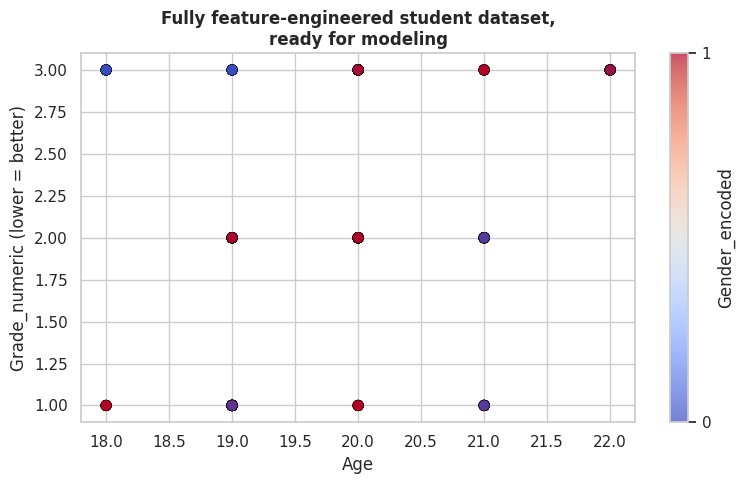

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['Age'], df['Grade_numeric'], c=df['Gender_encoded'], cmap='coolwarm',
                      s=60, alpha=0.7, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Age')
ax.set_ylabel('Grade_numeric (lower = better)')
ax.set_title('Fully feature-engineered student dataset,\nready for modeling', fontweight='bold', fontsize=12)
plt.colorbar(scatter, label='Gender_encoded', ticks=[0, 1])
plt.tight_layout()
plt.show()

## 4. Save the final, modeling-ready dataset

In [16]:
df.to_csv(os.path.join(EXPORT_DIR, 'student_label_encoded.csv'), index=False)
print(f"Saved student_label_encoded.csv -- {df.shape[0]} rows, {df.shape[1]} columns")
print("\nThis completes the Student feature-engineering pipeline:")
print("  student.csv -> student_feature_split.csv -> student_feature_extraction.csv -> student_label_encoded.csv")

Saved student_label_encoded.csv -- 232 rows, 10 columns

This completes the Student feature-engineering pipeline:
  student.csv -> student_feature_split.csv -> student_feature_extraction.csv -> student_label_encoded.csv


---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Yes/No → 1/0 | `s.map({'yes': 1, 'no': 0})` |
| Ordinal grade → number | `s.map({'1st Class': 1, '2nd Class': 2})` |
| Age bands | `pd.cut(s, [0,25,40,np.inf], labels=[…])` |
| Flag from a condition | `(df['age'] < 25).astype(int)` |
| Label encode | `LabelEncoder().fit_transform(s)` |
| Check the mapping | `dict(zip(le.classes_, range(len(le.classes_))))` |

### Adapting this in the exam

- The pipeline shape is identical across datasets. Learn the shape, then substitute the column names.
- Grade, rating, satisfaction, size, priority — all ordinal. Map them explicitly and say why.

### Traps that cost marks

- `.map()` returns `NaN` for any value not in your dictionary — check for new blanks afterwards.
- Grades are **ordinal**: use an explicit `.map()` so 1st < 2nd < 3rd, not `LabelEncoder`, which sorts alphabetically.
- `pd.cut` band labels must number one fewer than the boundaries.
- Run the stages in order — each reads the previous stage's output.